> **Course notebook 8** | [Course home](../README.md) | [Previous: Simplified self-attention](07_simplified_self_attention_from_scratch.ipynb)

This notebook adds trainable Query/Key/Value projections and one new rule: future positions are hidden.

# Causal Attention from Scratch

GPT predicts text from left to right. Causal attention adds one simple rule:

> **A token may use itself and earlier tokens, but not future tokens.**

We will build that rule visually, apply it to one attention head, and finish with a small reusable PyTorch class.

In [36]:
import math

import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.manual_seed(123)
np.random.seed(123)
torch.set_printoptions(precision=4, sci_mode=False)
plt.rcParams.update({"figure.figsize": (8.5, 4), "font.size": 11})

COLORS = {
    "blue": "#3b82f6",
    "orange": "#f59e0b",
    "green": "#10b981",
    "red": "#ef4444",
    "purple": "#8b5cf6",
    "gray": "#64748b",
}


def print_table(headers, rows):
    '''Print a small dependency-free table.'''
    string_rows = [[str(value) for value in row] for row in rows]
    widths = [
        max(len(str(header)), *(len(row[i]) for row in string_rows))
        for i, header in enumerate(headers)
    ]
    print(" | ".join(str(h).ljust(widths[i]) for i, h in enumerate(headers)))
    print("-+-".join("-" * width for width in widths))
    for row in string_rows:
        print(" | ".join(value.ljust(widths[i]) for i, value in enumerate(row)))


def heatmap(values, row_labels, column_labels, title, colorbar_label,
            cmap="Blues", value_format=".2f", mask_x=False):
    '''Draw a labeled, annotated matrix heatmap.'''
    array = np.asarray(values)
    plot_array = np.where(np.isfinite(array), array, np.nan)
    fig, ax = plt.subplots(figsize=(7.3, 5.5))
    image = ax.imshow(plot_array, cmap=cmap)
    ax.set_xticks(range(len(column_labels)), column_labels, rotation=35, ha="right")
    ax.set_yticks(range(len(row_labels)), row_labels)
    ax.set_xlabel("Key / candidate token")
    ax.set_ylabel("Query token")
    ax.set_title(title)
    finite = array[np.isfinite(array)]
    threshold = (finite.min() + finite.max()) / 2 if finite.size else 0
    for row in range(array.shape[0]):
        for col in range(array.shape[1]):
            value = array[row, col]
            if not np.isfinite(value):
                label = "−∞" if mask_x else "×"
                color = COLORS["red"]
            else:
                label = format(value, value_format)
                color = "white" if value > threshold else "black"
            ax.text(col, row, label, ha="center", va="center", color=color, fontsize=9)
    fig.colorbar(image, ax=ax, label=colorbar_label)
    plt.tight_layout()
    plt.show()


print("PyTorch:", torch.__version__)
print("Random seed: 123")

PyTorch: 2.9.1+cpu
Random seed: 123


## 0. Where this lesson fits

```text
Simplified attention → trainable Q/K/V → causal attention ← YOU ARE HERE
                                              ↓
                                      multi-head attention
```

This notebook briefly introduces trainable Query, Key, and Value projections because they are needed by the causal-attention class. Multi-head attention comes later.

## 1. Sentence and input embeddings

We use six words as six educational tokens:

```text
your | journey | starts | with | one | step
```

Real GPT tokenizers use subwords, so a word is not always one token. Each row below is a small input embedding for one position.

> **Illustrative values for learning — not embeddings learned by a real LLM.**

In [37]:
tokens = ["your", "journey", "starts", "with", "one", "step"]
inputs = torch.tensor([
    [0.20, 0.50, 0.30],
    [0.80, 0.60, 0.40],
    [0.75, 0.55, 0.35],
    [0.10, 0.70, 0.20],
    [0.00, 0.20, 0.90],
    [0.65, 0.35, 0.50],
], dtype=torch.float32)

print_table(
    ["token", "dim 1", "dim 2", "dim 3"],
    [
        [token, *(f"{value:.2f}" for value in vector.tolist())]
        for token, vector in zip(tokens, inputs)
    ],
)
print("\nX.shape:", tuple(inputs.shape), "= 6 tokens × 3 dimensions")

token   | dim 1 | dim 2 | dim 3
--------+-------+-------+------
your    | 0.20  | 0.50  | 0.30 
journey | 0.80  | 0.60  | 0.40 
starts  | 0.75  | 0.55  | 0.35 
with    | 0.10  | 0.70  | 0.20 
one     | 0.00  | 0.20  | 0.90 
step    | 0.65  | 0.35  | 0.50 

X.shape: (6, 3) = 6 tokens × 3 dimensions


**What to notice:** `X.shape = (6,3)` means six token positions with three values per token.

## 2. Query, Key, and Value

Each input is transformed in three ways:

```text
X ─┬─→ Q: what am I looking for?
   ├─→ K: what do I match?
   └─→ V: what information do I contribute?
```

\[
Q=XW_Q,\qquad K=XW_K,\qquad V=XW_V
\]

The `W` matrices are trainable in a model. We use fixed values here so results remain repeatable.

In [3]:
d_in, d_k, d_v = 3, 2, 2

W_query = torch.tensor([
    [0.80, -0.30],
    [0.20,  0.90],
    [-0.50, 0.40],
])
W_key = torch.tensor([
    [0.40,  0.70],
    [-0.20, 0.60],
    [0.90, -0.10],
])
W_value = torch.tensor([
    [0.60,  0.10],
    [0.30,  0.80],
    [-0.20, 0.50],
])

queries = inputs @ W_query
keys = inputs @ W_key
values = inputs @ W_value

for name, tensor in [("X", inputs), ("W_Q", W_query), ("Q", queries),
                     ("W_K", W_key), ("K", keys), ("W_V", W_value), ("V", values)]:
    print(f"{name:>3}.shape = {tuple(tensor.shape)}")

print("\nQ =\n", queries)
print("\nK =\n", keys)
print("\nV =\n", values)

  X.shape = (6, 3)
W_Q.shape = (3, 2)
  Q.shape = (6, 2)
W_K.shape = (3, 2)
  K.shape = (6, 2)
W_V.shape = (3, 2)
  V.shape = (6, 2)

Q =
 tensor([[ 0.1100,  0.5100],
        [ 0.5600,  0.4600],
        [ 0.5350,  0.4100],
        [ 0.1200,  0.6800],
        [-0.4100,  0.5400],
        [ 0.3400,  0.3200]])

K =
 tensor([[0.2500, 0.4100],
        [0.5600, 0.8800],
        [0.5050, 0.8200],
        [0.0800, 0.4700],
        [0.7700, 0.0300],
        [0.6400, 0.6150]])

V =
 tensor([[ 0.2100,  0.5700],
        [ 0.5800,  0.7600],
        [ 0.5450,  0.6900],
        [ 0.2300,  0.6700],
        [-0.1200,  0.6100],
        [ 0.3950,  0.5950]])


**Shapes:** `(6×3) @ (3×2) = (6×2)`. Query and Key create scores; Value supplies the information that will be mixed.

## 3. Attention scores and scaling

Every Query is compared with every Key:

\[
S=
rac{QK^T}{\sqrt{d_k}}
\]

`QKᵀ` produces a `(6,6)` matrix: one query per row and one key per column. Dividing by `√d_k` prevents dot products from becoming unnecessarily large as the feature dimension grows.

Q.shape: (6, 2)
K.T.shape: (2, 6)
S.shape: (6, 6)
S[journey, your]: 0.3286000192165375
S[journey, step]: 0.6412999629974365


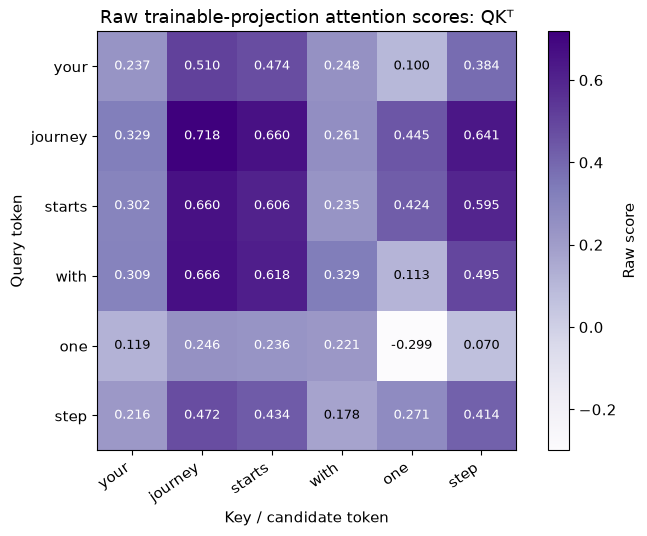

In [4]:
raw_scores = queries @ keys.T

print("Q.shape:", tuple(queries.shape))
print("K.T.shape:", tuple(keys.T.shape))
print("S.shape:", tuple(raw_scores.shape))
print("S[journey, your]:", raw_scores[1, 0].item())
print("S[journey, step]:", raw_scores[1, 5].item())

heatmap(
    raw_scores.numpy(), tokens, tokens,
    "Raw trainable-projection attention scores: QKᵀ",
    "Raw score", cmap="Purples", value_format=".3f",
)

**What to notice:** one row contains one token's scores against all six token positions.

## 4. Ordinary self-attention can see the future

Softmax turns the scaled scores into weights. Without a mask, every token can attend to every position.

full_attention_weights.shape: (6, 6)
row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

Journey can currently use: ['your', 'journey', 'starts', 'with', 'one', 'step']


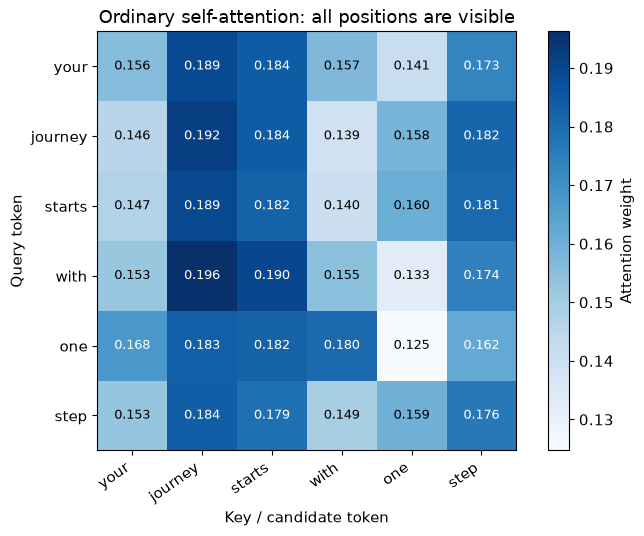

In [6]:
scaled_scores = raw_scores / math.sqrt(d_k)
full_attention_weights = torch.softmax(scaled_scores, dim=-1)

print("full_attention_weights.shape:", tuple(full_attention_weights.shape))
print("row sums:", full_attention_weights.sum(dim=-1))
print("\nJourney can currently use:", tokens)

heatmap(
    full_attention_weights.numpy(), tokens, tokens,
    "Ordinary self-attention: all positions are visible",
    "Attention weight", cmap="Blues", value_format=".3f",
)

**What to notice:** the *journey* row currently has nonzero weights for later words such as *starts* and *step*.

## 5. Why GPT needs a causal rule

When processing *journey*, GPT may use:

```text
your, journey
```

It must not use:

```text
starts, with, one, step
```

Those are future tokens—the answers the model is learning to predict.

## 6. The visibility pattern

Each row gains one additional visible position:

| Query | Allowed tokens |
|---|---|
| your | your |
| journey | your, journey |
| starts | your, journey, starts |
| with | your, journey, starts, with |
| one | your, journey, starts, with, one |
| step | all six |

tensor([[1, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1]], dtype=torch.int32)


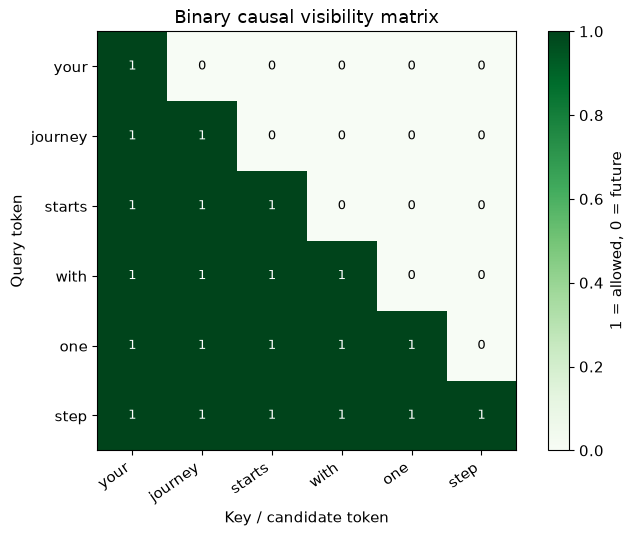

In [7]:
context_length = len(tokens)
allowed_mask = torch.tril(torch.ones(context_length, context_length))

print(allowed_mask.to(torch.int))
heatmap(
    allowed_mask.numpy(), tokens, tokens,
    "Binary causal visibility matrix",
    "1 = allowed, 0 = future", cmap="Greens", value_format=".0f",
)

**What to notice:** the diagonal and lower triangle are visible. The upper triangle contains future positions.

## 7. Mark the future positions

`torch.triu(..., diagonal=1)` creates the upper-triangular mask. A `1` means “hide this future position.”

In [9]:
future_mask = torch.triu(
    torch.ones(context_length, context_length, dtype=torch.bool),
    diagonal=1,
)

print("future mask (1 = hide):\n", future_mask.to(torch.int))
print("shape:", tuple(future_mask.shape))

future mask (1 = hide):
 tensor([[0, 1, 1, 1, 1, 1],
        [0, 0, 1, 1, 1, 1],
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0]], dtype=torch.int32)
shape: (6, 6)


**What to notice:** the diagonal is not masked, so each token may still use itself.

## 8. Replace future scores with `−∞`

The standard implementation masks scores before softmax:

```python
masked_scores = scaled_scores.masked_fill(mask, float("-inf"))
```

Shapes stay unchanged; only forbidden score values change.

scaled scores:
 tensor([[ 0.1673,  0.3609,  0.3350,  0.1757,  0.0707,  0.2716],
        [ 0.2324,  0.5080,  0.4667,  0.1846,  0.3147,  0.4535],
        [ 0.2134,  0.4670,  0.4288,  0.1665,  0.3000,  0.4204],
        [ 0.2184,  0.4707,  0.4371,  0.2328,  0.0798,  0.3500],
        [ 0.0841,  0.1737,  0.1667,  0.1563, -0.2118,  0.0493],
        [ 0.1529,  0.3338,  0.3070,  0.1256,  0.1919,  0.2930]])

mask (True = hide):
 tensor([[False,  True,  True,  True,  True,  True],
        [False, False,  True,  True,  True,  True],
        [False, False, False,  True,  True,  True],
        [False, False, False, False,  True,  True],
        [False, False, False, False, False,  True],
        [False, False, False, False, False, False]])

masked scores:
 tensor([[ 0.1673,    -inf,    -inf,    -inf,    -inf,    -inf],
        [ 0.2324,  0.5080,    -inf,    -inf,    -inf,    -inf],
        [ 0.2134,  0.4670,  0.4288,    -inf,    -inf,    -inf],
        [ 0.2184,  0.4707,  0.4371,  0.2328,    -inf,  

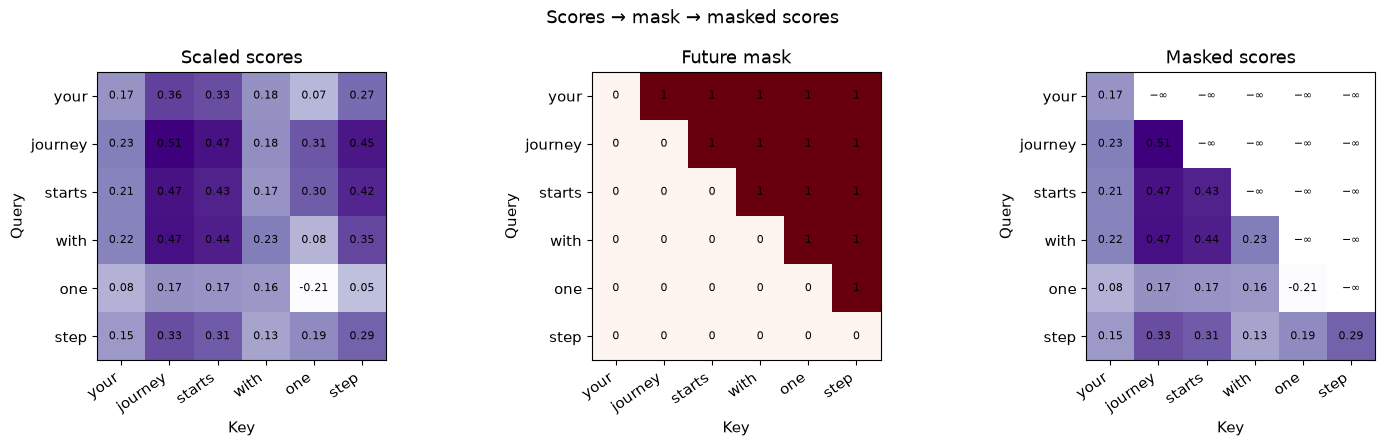

In [14]:
mask = torch.triu(
    torch.ones(context_length, context_length, dtype=torch.bool),
    diagonal=1,
)
masked_scores = scaled_scores.masked_fill(mask, float("-inf"))

print("scaled scores:\n", scaled_scores)
print("\nmask (True = hide):\n", mask)
print("\nmasked scores:\n", masked_scores)
print("\nshapes:", tuple(scaled_scores.shape), tuple(mask.shape), tuple(masked_scores.shape))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
displays = [
    (scaled_scores.numpy(), "Scaled scores", "Purples"),
    (mask.numpy().astype(float), "Future mask", "Reds"),
    (masked_scores.numpy(), "Masked scores", "Purples"),
]
for ax, (array, title, cmap) in zip(axes, displays):
    shown = np.where(np.isfinite(array), array, np.nan)
    ax.imshow(shown, cmap=cmap)
    ax.set_xticks(range(6), tokens, rotation=35, ha="right")
    ax.set_yticks(range(6), tokens)
    ax.set_xlabel("Key")
    ax.set_ylabel("Query")
    ax.set_title(title)
    for row in range(6):
        for col in range(6):
            if title == "Future mask":
                label = str(int(array[row, col]))
            elif np.isfinite(array[row, col]):
                label = f"{array[row, col]:.2f}"
            else:
                label = "−∞"
            ax.text(col, row, label, ha="center", va="center", fontsize=8)
fig.suptitle("Scores → mask → masked scores")
plt.tight_layout()
plt.show()

**Why `−∞`?** Softmax uses exponentials, and `exp(−∞)=0`. Future positions therefore receive exactly zero weight.

## 9. Apply softmax

Row-wise softmax normalizes the remaining allowed scores.

In [15]:
causal_attention_weights = torch.softmax(masked_scores, dim=-1)
causal_row_sums = causal_attention_weights.sum(dim=-1)
future_weights = causal_attention_weights.masked_select(mask)

print("causal weights:\n", causal_attention_weights)
print("\nrow sums:", causal_row_sums)
print("future entries all zero:", bool(torch.all(future_weights == 0)))

assert torch.allclose(causal_row_sums, torch.ones(context_length))
assert torch.all(future_weights == 0)

causal weights:
 tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4315, 0.5685, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2834, 0.3652, 0.3515, 0.0000, 0.0000, 0.0000],
        [0.2200, 0.2831, 0.2738, 0.2232, 0.0000, 0.0000],
        [0.2001, 0.2188, 0.2173, 0.2150, 0.1488, 0.0000],
        [0.1532, 0.1836, 0.1787, 0.1491, 0.1593, 0.1762]])

row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])
future entries all zero: True


**What to notice:** before dropout, each row sums to 1 and every value above the diagonal is zero.

## 10. Read the causal heatmap

The staircase pattern shows that later queries may use more history.

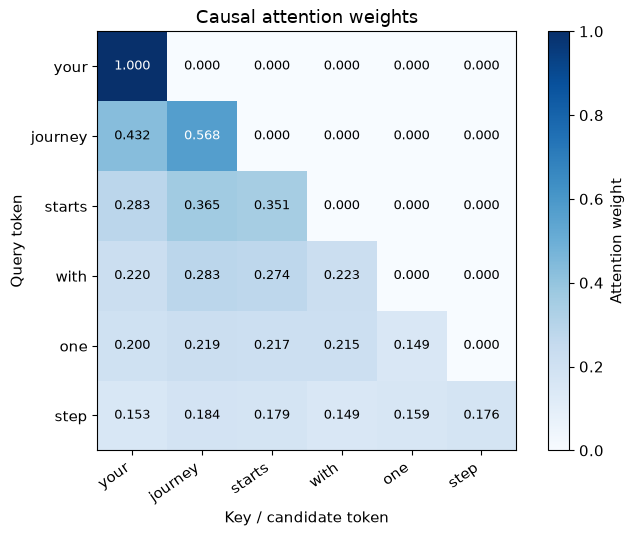

In [16]:
heatmap(
    causal_attention_weights.numpy(), tokens, tokens,
    "Causal attention weights",
    "Attention weight", cmap="Blues", value_format=".3f",
)

**Concept check:** *journey* can use two positions; *step* can use all six.

## 11. Inspect individual queries

The helper displays which tokens are allowed, which are masked, and the final weights for one query.

Query: journey
Allowed: ['your', 'journey']
Masked:  ['starts', 'with', 'one', 'step']


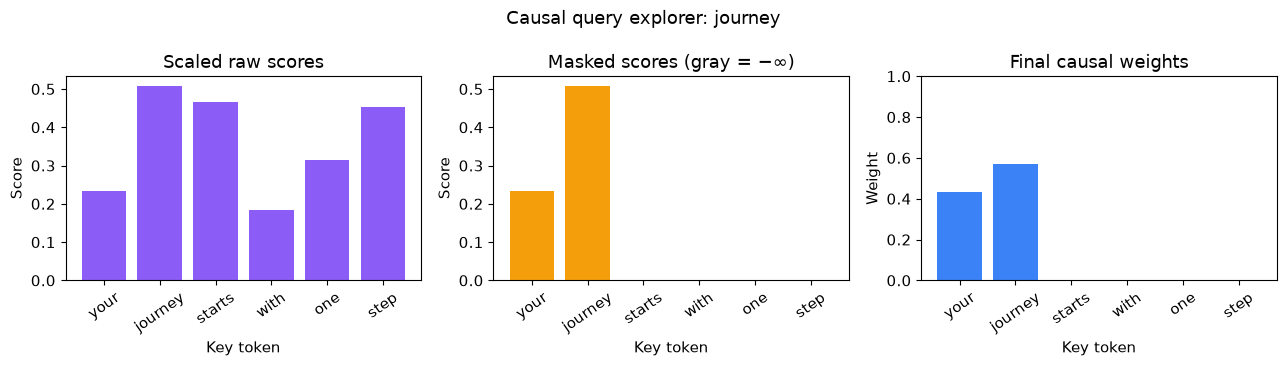

Query: with
Allowed: ['your', 'journey', 'starts', 'with']
Masked:  ['one', 'step']


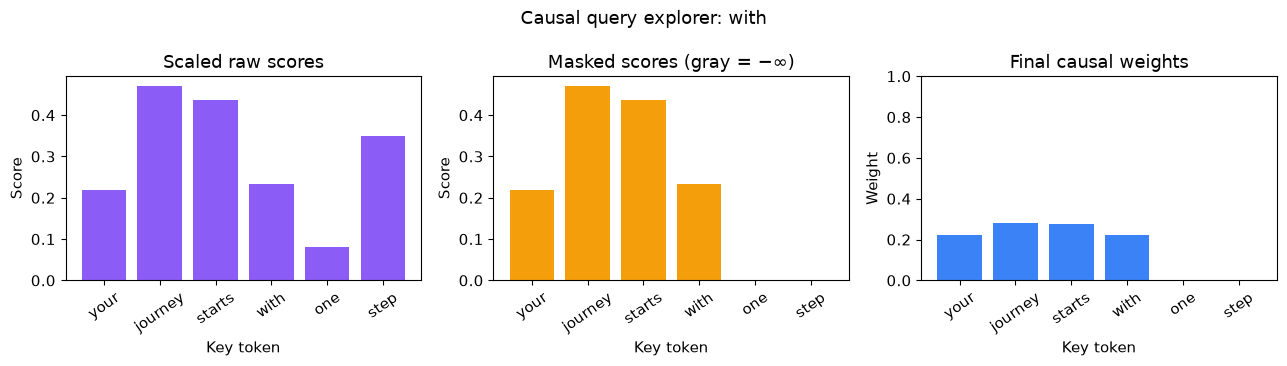

Query: step
Allowed: ['your', 'journey', 'starts', 'with', 'one', 'step']
Masked:  none


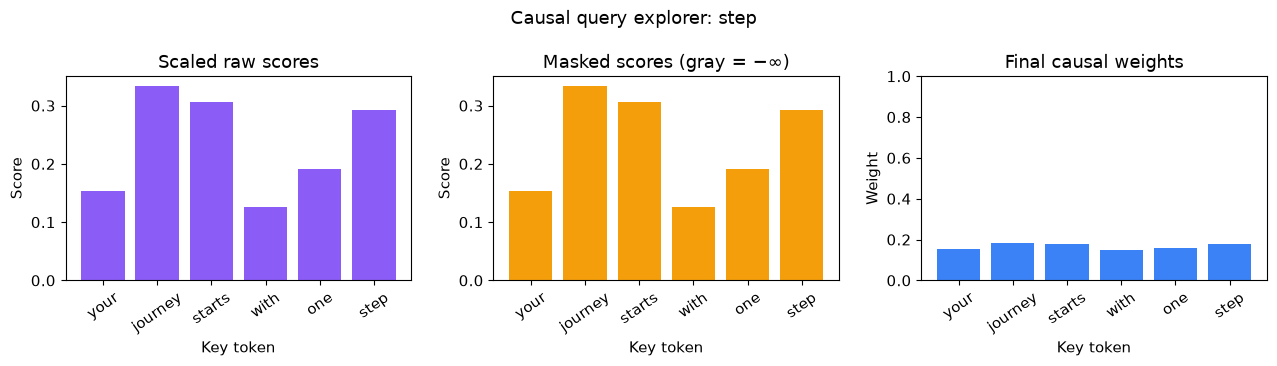

In [17]:
def visualize_causal_query(token_index):
    if token_index not in range(context_length):
        raise ValueError(f"token_index must be 0 through {context_length-1}")

    allowed = tokens[:token_index + 1]
    blocked = tokens[token_index + 1:]
    print(f"Query: {tokens[token_index]}")
    print("Allowed:", allowed)
    print("Masked: ", blocked if blocked else "none")

    raw_row = scaled_scores[token_index]
    masked_row = masked_scores[token_index]
    weight_row = causal_attention_weights[token_index]

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.7))
    axes[0].bar(tokens, raw_row.numpy(), color=COLORS["purple"])
    axes[0].set(title="Scaled raw scores", ylabel="Score")
    masked_display = torch.where(torch.isfinite(masked_row), masked_row, torch.nan)
    axes[1].bar(tokens, torch.nan_to_num(masked_display).numpy(),
                color=[COLORS["gray"] if torch.isnan(v) else COLORS["orange"]
                       for v in masked_display])
    axes[1].set(title="Masked scores (gray = −∞)", ylabel="Score")
    axes[2].bar(tokens, weight_row.numpy(), color=COLORS["blue"])
    axes[2].set(title="Final causal weights", ylabel="Weight", ylim=(0, 1))
    for ax in axes:
        ax.set_xlabel("Key token")
        ax.tick_params(axis="x", rotation=35)
    fig.suptitle(f"Causal query explorer: {tokens[token_index]}")
    plt.tight_layout()
    plt.show()


visualize_causal_query(1)  # journey
visualize_causal_query(3)  # with
visualize_causal_query(5)  # step

**Try it:** compare *journey*, *with*, and *step*. The allowed region grows from left to right.

## 12. Create context vectors

\[
Z = A_{causal}V
\]

Weights decide **how much** to take. Value vectors provide **what** is taken. The *journey* context can combine only the first two Values.

In [18]:
causal_context_vectors = causal_attention_weights @ values

print("A.shape:", tuple(causal_attention_weights.shape))
print("V.shape:", tuple(values.shape))
print("Z.shape:", tuple(causal_context_vectors.shape))
print("\nJourney weights:", causal_attention_weights[1])
print("Journey context:", causal_context_vectors[1])
print("Step weights:", causal_attention_weights[5])
print("Step context:", causal_context_vectors[5])

journey_manual = (
    causal_attention_weights[1, 0] * values[0]
    + causal_attention_weights[1, 1] * values[1]
)
print("Journey uses v1 and v2 only:", torch.allclose(
    journey_manual, causal_context_vectors[1]
))

A.shape: (6, 6)
V.shape: (6,)
Z.shape: (6,)

Journey weights: tensor([0.4315, 0.5685, 0.0000, 0.0000, 0.0000, 0.0000])
Journey context: tensor(0.5171)
Step weights: tensor([0.1532, 0.1836, 0.1787, 0.1491, 0.1593, 0.1762])
Step context: tensor(0.1722)
Journey uses v1 and v2 only: True


**What to notice:** `(6×6) @ (6×2) = (6×2)`, so every token receives one two-dimensional context vector.

## 13. The complete one-sequence idea

```text
X → Q, K, V → scaled QKᵀ → mask future scores
  → softmax → causal weights → weighted Values → context
```

Causal masking lets GPT train many positions in parallel without allowing a position to peek at later targets.

## 14. Attention dropout

During training, dropout randomly removes some **allowed** attention connections. Surviving values are rescaled. Masked future connections stay zero.

After dropout, rows do not necessarily sum to 1; this is expected. During evaluation, dropout is disabled.

row sums before dropout: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])
row sums after dropout:  tensor([2.0000, 0.8631, 2.0000, 0.4399, 0.2976, 1.0381])
future entries still zero: True


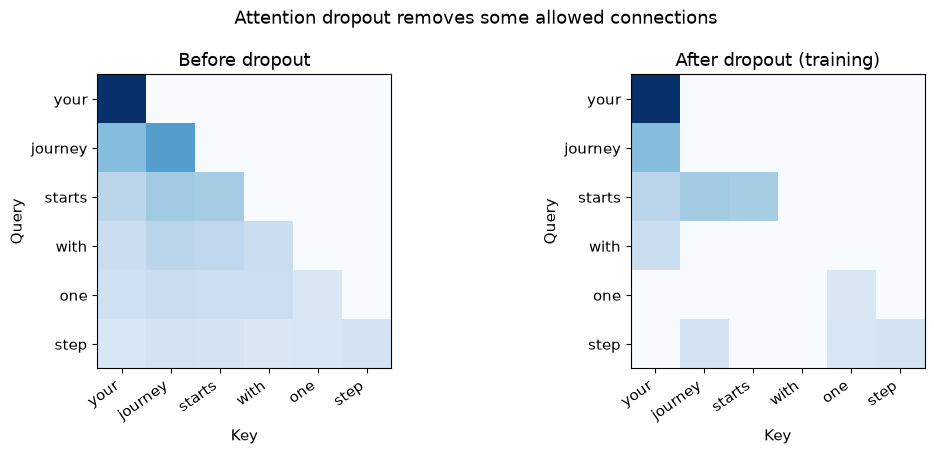

In [22]:
torch.manual_seed(7)
attention_dropout = nn.Dropout(p=0.5)
attention_dropout.train()
dropped_attention = attention_dropout(causal_attention_weights)

print("row sums before dropout:", causal_attention_weights.sum(dim=-1))
print("row sums after dropout: ", dropped_attention.sum(dim=-1))
print("future entries still zero:", bool(torch.all(dropped_attention.masked_select(mask) == 0)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, matrix, title in [
    (axes[0], causal_attention_weights.numpy(), "Before dropout"),
    (axes[1], dropped_attention.numpy(), "After dropout (training)"),
]:
    ax.imshow(matrix, cmap="Blues", vmin=0)
    ax.set_xticks(range(6), tokens, rotation=35, ha="right")
    ax.set_yticks(range(6), tokens)
    ax.set_xlabel("Key")
    ax.set_ylabel("Query")
    ax.set_title(title)
fig.suptitle("Attention dropout removes some allowed connections")
plt.tight_layout()
plt.show()

**What to notice:** causal zeros remain zero, while some allowed connections are temporarily dropped during training.

In [23]:
torch.manual_seed(11)
mode_dropout = nn.Dropout(p=0.5)

mode_dropout.train()
training_result = mode_dropout(causal_attention_weights)

mode_dropout.eval()
evaluation_result = mode_dropout(causal_attention_weights)

print("training changed tensor:", not torch.allclose(
    training_result, causal_attention_weights
))
print("evaluation unchanged:", torch.allclose(
    evaluation_result, causal_attention_weights
))

training changed tensor: True
evaluation unchanged: True


`train()` activates dropout; `eval()` disables it for deterministic inference and testing.

## 15. Single-sequence pipeline

```text
X ─→ Q, K, V
QKᵀ ÷ √d_k
      ↓ mask future with −∞
      ↓ softmax
causal weights
      ↓ optional training dropout
      ↓ @ V
context vectors
```

## 16. Add a batch dimension

One sequence is `(T,d_in)=(6,3)`. Two sequences become:

```text
(B,T,d_in) = (2,6,3)
```

PyTorch performs the same projections and attention calculation independently for each batch item.

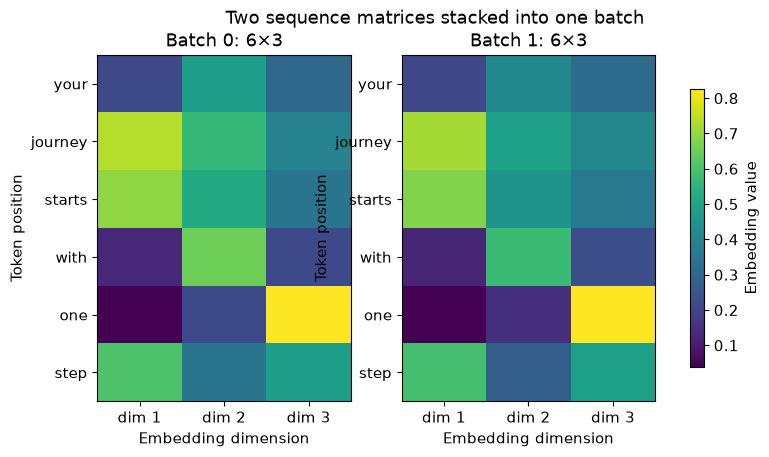

batch.shape: (2, 6, 3)


In [24]:
second_sequence = inputs * 0.85 + torch.tensor([0.04, -0.02, 0.06])
batch = torch.stack([inputs, second_sequence])

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
for index, ax in enumerate(axes):
    image = ax.imshow(batch[index].numpy(), cmap="viridis", aspect="auto")
    ax.set_xticks(range(3), ["dim 1", "dim 2", "dim 3"])
    ax.set_yticks(range(6), tokens)
    ax.set_xlabel("Embedding dimension")
    ax.set_ylabel("Token position")
    ax.set_title(f"Batch {index}: 6×3")
fig.colorbar(image, ax=axes, label="Embedding value", shrink=0.8)
fig.suptitle("Two sequence matrices stacked into one batch")
plt.show()

print("batch.shape:", tuple(batch.shape))

**What to notice:** the leading dimension separates two independent sequences.

In [25]:
batch_queries = batch @ W_query
batch_keys = batch @ W_key
batch_values = batch @ W_value

print("batch X:", tuple(batch.shape))
print("W_Q:", tuple(W_query.shape), "→ Q:", tuple(batch_queries.shape))
print("W_K:", tuple(W_key.shape), "→ K:", tuple(batch_keys.shape))
print("W_V:", tuple(W_value.shape), "→ V:", tuple(batch_values.shape))

batch X: (2, 6, 3)
W_Q: (3, 2) → Q: (2, 6, 2)
W_K: (3, 2) → K: (2, 6, 2)
W_V: (3, 2) → V: (2, 6, 2)


The projection preserves batch and token axes: `(2,6,3) @ (3,2) = (2,6,2)`.

In [26]:
batch_scores = batch_queries @ batch_keys.transpose(-2, -1)

print("Q.shape:", tuple(batch_queries.shape))
print("K.shape:", tuple(batch_keys.shape))
print("K transposed:", tuple(batch_keys.transpose(-2, -1).shape))
print("scores.shape:", tuple(batch_scores.shape))

Q.shape: (2, 6, 2)
K.shape: (2, 6, 2)
K transposed: (2, 2, 6)
scores.shape: (2, 6, 6)


`K.transpose(-2,-1)` swaps only token and feature axes, producing batched scores shaped `(B,T,T)`.

## 17. Reuse one mask across the batch

Scores are `(B,T,T)` and the mask is `(T,T)`. Broadcasting applies the same causal visibility rule independently to every batch item.

In [27]:
batch_scaled_scores = batch_scores / math.sqrt(d_k)
batched_masked_scores = batch_scaled_scores.masked_fill(mask, float("-inf"))

expanded_mask = mask.unsqueeze(0).expand(batch.shape[0], -1, -1)
explicit_masked_scores = batch_scaled_scores.masked_fill(
    expanded_mask, float("-inf")
)

print("scores.shape:", tuple(batch_scaled_scores.shape))
print("mask.shape:", tuple(mask.shape))
print("broadcast result:", tuple(batched_masked_scores.shape))
print("broadcast equals explicit expansion:", torch.allclose(
    batched_masked_scores, explicit_masked_scores
))

scores.shape: (2, 6, 6)
mask.shape: (6, 6)
broadcast result: (2, 6, 6)
broadcast equals explicit expansion: True


**What to notice:** broadcasting avoids copying the mask manually, and batches never attend to one another.

## 18. A reusable one-head class

The class combines projections, scaling, masking, softmax, dropout, and Value mixing.

The mask is registered as a **buffer**: it moves with the model but is not trainable. If the current sequence is shorter than the maximum context length, the class uses `mask[:T,:T]`.

In [30]:
class CausalAttention(nn.Module):
    def __init__(self, d_in, d_k, d_v, context_length, dropout=0.0):
        super().__init__()
        self.d_k = d_k
        self.W_query = nn.Linear(d_in, d_k, bias=False)
        self.W_key = nn.Linear(d_in, d_k, bias=False)
        self.W_value = nn.Linear(d_in, d_v, bias=False)
        self.dropout = nn.Dropout(dropout)

        self.register_buffer(
            "mask",
            torch.triu(
                torch.ones(
                    context_length, context_length, dtype=torch.bool
                ),
                diagonal=1,
            ),
        )

    def forward(self, x, return_details=False):
        B, T, _ = x.shape
        if T > self.mask.shape[0]:
            raise ValueError(
                f"Sequence length {T} exceeds context length "
                f"{self.mask.shape[0]}"
            )

        queries = self.W_query(x)  # (B,T,d_k)
        keys = self.W_key(x)       # (B,T,d_k)
        values = self.W_value(x)   # (B,T,d_v)

        scores = queries @ keys.transpose(-2, -1)
        scores = scores / math.sqrt(self.d_k)
        active_mask = self.mask[:T, :T]
        masked_scores = scores.masked_fill(active_mask, float("-inf"))

        weights_before_dropout = torch.softmax(masked_scores, dim=-1)
        weights = self.dropout(weights_before_dropout)
        context = weights @ values

        if return_details:
            details = {
                "queries": queries,
                "keys": keys,
                "values": values,
                "scores": scores,
                "masked_scores": masked_scores,
                "weights_before_dropout": weights_before_dropout,
                "weights_after_dropout": weights,
            }
            return context, details
        return context

**What to notice:** the `nn.Linear` weights learn; the fixed Boolean visibility mask does not.

## 19. Run the class

For two six-token sequences:

```text
input  (2,6,3) → causal attention → output (2,6,2)
```

In [31]:
torch.manual_seed(123)
causal_head = CausalAttention(
    d_in=3, d_k=2, d_v=2, context_length=6, dropout=0.2
)
causal_head.eval()  # deterministic inspection

class_context, class_details = causal_head(batch, return_details=True)

print("x:       ", tuple(batch.shape))
for name in ["queries", "keys", "values", "scores",
             "masked_scores", "weights_before_dropout"]:
    print(f"{name:<22}", tuple(class_details[name].shape))
print("context: ", tuple(class_context.shape))

x:        (2, 6, 3)
queries                (2, 6, 2)
keys                   (2, 6, 2)
values                 (2, 6, 2)
scores                 (2, 6, 6)
masked_scores          (2, 6, 6)
weights_before_dropout (2, 6, 6)
context:  (2, 6, 2)


Scores and weights are `(B,T,T)`; context ends in the Value dimension `d_v`.

## 20. Verify the mask

Two useful checks are:

1. every future weight is zero;
2. every pre-dropout row sums to 1.

In [32]:
pre_dropout_weights = class_details["weights_before_dropout"]
active_future_mask = causal_head.mask[:batch.shape[1], :batch.shape[1]]
broadcast_future_mask = active_future_mask.unsqueeze(0).expand(
    batch.shape[0], -1, -1
)

future_are_zero = torch.all(
    pre_dropout_weights.masked_select(broadcast_future_mask) == 0
)
rows_sum_to_one = torch.allclose(
    pre_dropout_weights.sum(dim=-1),
    torch.ones(batch.shape[0], batch.shape[1]),
)

print("future weights are zero:", bool(future_are_zero))
print("rows sum to one:", rows_sum_to_one)
assert future_are_zero
assert rows_sum_to_one

future weights are zero: True
rows sum to one: True


These assertions catch common mask-direction and softmax-dimension mistakes.

## 21. The most important causality test

Compare two sequences with the same first three positions but different futures:

```text
A B C D E F
A B C X Y Z
```

Under causal attention, outputs for A, B, and C must remain identical because they cannot see the changed future.

Causal first 3 match: True
Unmasked first 3 match: False
max causal prefix difference: 0.0
max unmasked prefix difference: 0.12030379474163055


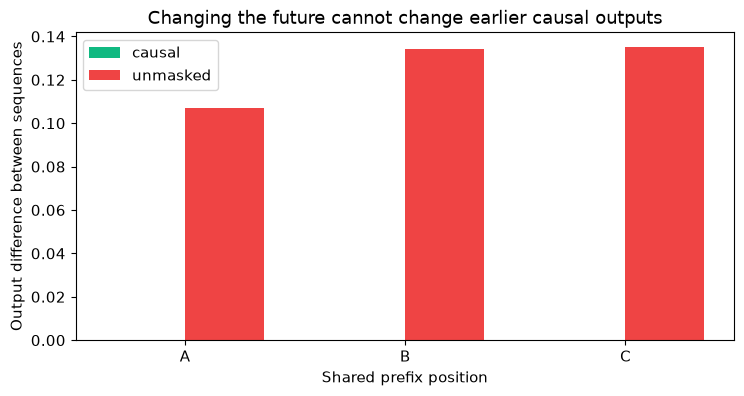

In [33]:
future_a = torch.tensor([
    [0.10, 0.70, 0.20],
    [0.00, 0.20, 0.90],
    [0.65, 0.35, 0.50],
])
future_b = torch.tensor([
    [-0.80, 0.10, 1.10],
    [1.20, -0.60, 0.20],
    [-0.30, 1.30, -0.70],
])
shared_prefix = inputs[:3]
sequence_a = torch.cat([shared_prefix, future_a])
sequence_b = torch.cat([shared_prefix, future_b])
comparison_batch = torch.stack([sequence_a, sequence_b])

torch.manual_seed(99)
comparison_head = CausalAttention(
    d_in=3, d_k=2, d_v=2, context_length=6, dropout=0.0
)
comparison_head.eval()
causal_outputs, comparison_details = comparison_head(
    comparison_batch, return_details=True
)

q = comparison_head.W_query(comparison_batch)
k = comparison_head.W_key(comparison_batch)
v = comparison_head.W_value(comparison_batch)
unmasked_weights = torch.softmax(
    q @ k.transpose(-2, -1) / math.sqrt(comparison_head.d_k),
    dim=-1,
)
unmasked_outputs = unmasked_weights @ v

print("Causal first 3 match:", torch.allclose(
    causal_outputs[0, :3], causal_outputs[1, :3], atol=1e-6
))
print("Unmasked first 3 match:", torch.allclose(
    unmasked_outputs[0, :3], unmasked_outputs[1, :3], atol=1e-6
))
print("max causal prefix difference:",
      (causal_outputs[0, :3] - causal_outputs[1, :3]).abs().max().item())
print("max unmasked prefix difference:",
      (unmasked_outputs[0, :3] - unmasked_outputs[1, :3]).abs().max().item())

assert torch.allclose(causal_outputs[0, :3], causal_outputs[1, :3], atol=1e-6)

positions = ["A", "B", "C"]
causal_diff = (causal_outputs[0, :3] - causal_outputs[1, :3]).norm(dim=-1)
full_diff = (unmasked_outputs[0, :3] - unmasked_outputs[1, :3]).norm(dim=-1)
x_axis = np.arange(3)
plt.bar(x_axis - 0.18, causal_diff.detach().numpy(), 0.36,
        label="causal", color=COLORS["green"])
plt.bar(x_axis + 0.18, full_diff.detach().numpy(), 0.36,
        label="unmasked", color=COLORS["red"])
plt.xticks(x_axis, positions)
plt.xlabel("Shared prefix position")
plt.ylabel("Output difference between sequences")
plt.title("Changing the future cannot change earlier causal outputs")
plt.legend()
plt.show()

**What to notice:** causal prefix differences are zero; ordinary unmasked attention can change earlier outputs.

## 22. Shape reference

| Object | Shape |
|---|---|
| input `X` | `(B,T,d_in)` |
| `Q`, `K` | `(B,T,d_k)` |
| `V` | `(B,T,d_v)` |
| scores and weights | `(B,T,T)` |
| causal mask | `(T,T)` |
| context | `(B,T,d_v)` |

## 23. Common confusions

**Only the previous token?** No—every earlier token plus the current token is allowed.

**Why triangular?** Each successive position gains one more visible token.

**Do rows always sum to 1?** Before dropout, yes. After training dropout, not necessarily.

**Is the mask learned?** No. Q/K/V learn relevance; the mask only enforces visibility.

**Do batch elements interact?** No.

## 24. Practice

1. Draw the causal mask for four tokens.
2. Mask `[2,1,5,4]` for the second token.
3. Why does `−∞` become zero after softmax?
4. If `Q` and `K` are `(3,8,16)`, what shape is `Q @ K.transpose(-2,-1)`?
5. If weights are `(3,8,8)` and `V` is `(3,8,32)`, what is the context shape?
6. At zero-based index 4, which positions are visible?

### Quick theory check

1. What jobs do Query, Key, and Value perform?
2. Why scale scores by `√d_k`?
3. Why must GPT hide future positions?
4. Why does the mask start above the diagonal?
5. Why use `masked_fill(..., -inf)`?
6. What does row-wise softmax guarantee before dropout?
7. What changes between `train()` and `eval()`?
8. Why use `transpose(-2,-1)` for batched Keys?
9. Why register the mask as a buffer?
10. What does the causality experiment prove?

## Answers — check after attempting

<details>
<summary><strong>Practice answers</strong></summary>

1. Rows: `[1,0,0,0]`, `[1,1,0,0]`, `[1,1,1,0]`, `[1,1,1,1]`.
2. `[2,1,−∞,−∞]`.
3. `exp(−∞)=0`, so the softmax numerator is zero.
4. `(3,8,8)`.
5. `(3,8,32)`.
6. Positions `0,1,2,3,4`.
</details>

<details>
<summary><strong>Theory answers</strong></summary>

1. Query seeks, Key is matched, and Value supplies information.
2. To control dot-product magnitude.
3. Otherwise it could peek at prediction targets.
4. The diagonal remains visible so a token may use itself.
5. It directly gives future scores zero softmax weight.
6. Each query row sums to 1 over allowed positions.
7. Dropout is active in training and disabled in evaluation.
8. It swaps token and feature axes without moving the batch axis.
9. The fixed mask should move with the model but not be trained.
10. Changing future inputs cannot change earlier causal outputs.
</details>

## 25. Complete concept map

```text
Token embeddings → Q, K, V → scaled scores
                                  ↓
                           mask future with −∞
                                  ↓ softmax
                           causal weights
                                  ↓ @ Values
                           context vectors
                                  ↓
                        reusable one-head class
                                  ↓
                     NEXT: multi-head attention
```

## 26. Can I explain this?

- [ ] why GPT must hide future tokens
- [ ] Query, Key, Value, and scaled scores
- [ ] why the causal mask is triangular
- [ ] why `−∞` becomes zero after softmax
- [ ] how weights combine Value vectors
- [ ] basic dropout behavior
- [ ] `(B,T,d)` batching and `transpose(-2,-1)`
- [ ] why the mask is a buffer, not a parameter
- [ ] how the causality experiment proves future isolation

## 27. Final summary

```text
Q=XW_Q, K=XW_K, V=XW_V
            ↓
S = QKᵀ / √d_k
            ↓
future scores = −∞
            ↓
A = softmax(S)
            ↓
Z = A V
```

> **Q/K/V learn what is relevant. The causal mask only controls what each position is allowed to see.**

**Next:** several causal heads operating in parallel—Multi-Head Attention.